
# Traffic Data Visualization and Peak Hour Analysis

This analysis aims to identify peak traffic hours at different junctions using historical traffic data. 
The study also explores temporal patterns and the influence of external factors such as weather and events on traffic congestion.

In [1]:
#Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Load Dataset
df = pd.read_csv("processed_traffic_dataset.csv")

df["Date"] = pd.to_datetime(df["Date"])

df.head()

,Date,Junction,Traffic_Volume,Temperature,Rain,Humidity,Hour,Day_of_Week,Month,Weekend,Traffic_Lag1,Event_Festival,Event_Holiday,Event_Marathon,Event_Public_Event
0,2015-01-01 00:00:00,J1,-1.755539,-0.719874,0,0.000000,0,3,1,0,NaN,False,False,False,False
1,2015-01-01 01:00:00,J1,-1.633201,-0.719874,0,0.283410,1,3,1,0,120.0,False,False,False,False
2,2015-01-01 02:00:00,J2,-1.266190,-1.169795,1,1.417051,2,3,1,0,135.0,True,False,False,False
3,2015-01-01 03:00:00,J3,-1.103074,-1.169795,0,0.708525,3,3,1,0,180.0,False,True,False,False
4,2015-01-01 04:00:00,J1,-1.429306,-1.619717,0,0.425115,4,3,1,0,200.0,False,True,False,False


In [3]:
#Create Time Features
df["Hour"] = df["Date"].dt.hour
df["Day"] = df["Date"].dt.day_name()
df["Month"] = df["Date"].dt.month

In [4]:
#Congestion Metrics Calculation
hourly_congestion = df.groupby(["Junction","Hour"])["Traffic_Volume"].mean().reset_index()

hourly_congestion.head()

,Junction,Hour,Traffic_Volume
0,J1,0,-1.755539
1,J1,1,-1.633201
2,J1,4,-1.429306
3,J1,7,0.120298
4,J1,10,0.283414


Congestion is measured using the average traffic volume per hour for each junction.

In [5]:
#Peak Hour Identification
peak_hours = hourly_congestion.loc[
    hourly_congestion.groupby("Junction")["Traffic_Volume"].idxmax()
]

peak_hours

,Junction,Hour,Traffic_Volume
7,J1,19,1.343670
13,J2,17,1.180554
19,J3,18,1.506786


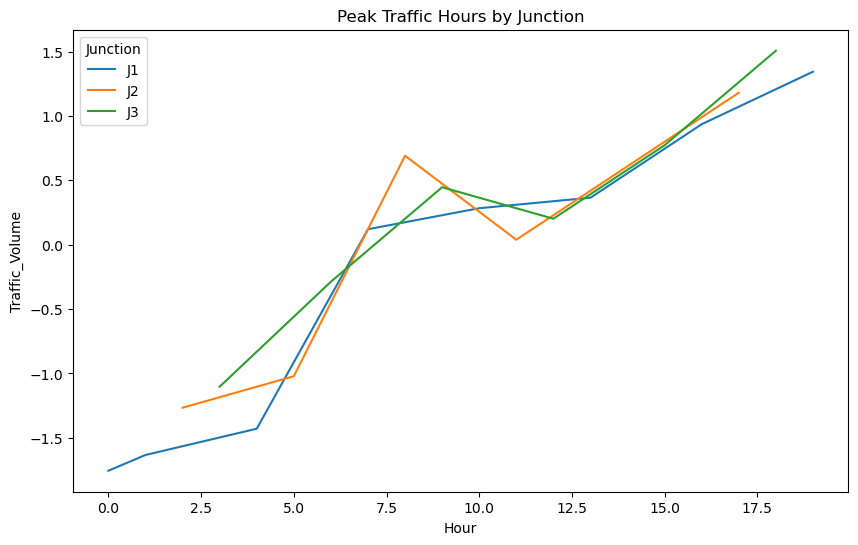

In [6]:
#Peak Hour Visualization
plt.figure(figsize=(10,6))

sns.lineplot(data=hourly_congestion,
             x="Hour",
             y="Traffic_Volume",
             hue="Junction")

plt.title("Peak Traffic Hours by Junction")
plt.show()

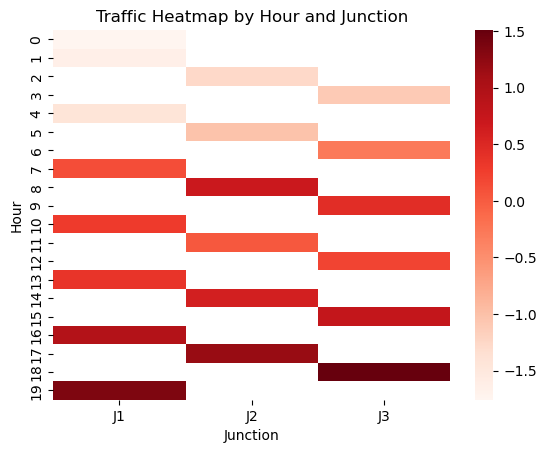

In [7]:
#Traffic Heatmap
pivot = df.pivot_table(values="Traffic_Volume",
                       index="Hour",
                       columns="Junction",
                       aggfunc="mean")

sns.heatmap(pivot, cmap="Reds")

plt.title("Traffic Heatmap by Hour and Junction")
plt.show()

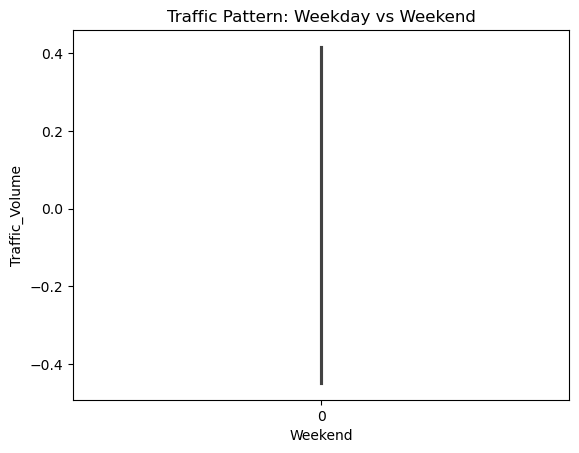

In [8]:
#Weekday vs Weekend Pattern
sns.barplot(data=df,
            x="Weekend",
            y="Traffic_Volume")

plt.title("Traffic Pattern: Weekday vs Weekend")
plt.show()

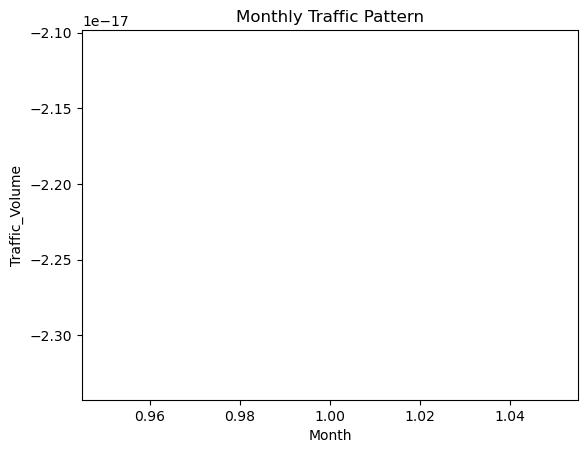

In [9]:
#Monthly Pattern Analysis
monthly_traffic = df.groupby("Month")["Traffic_Volume"].mean().reset_index()

sns.lineplot(data=monthly_traffic,
             x="Month",
             y="Traffic_Volume")

plt.title("Monthly Traffic Pattern")
plt.show()

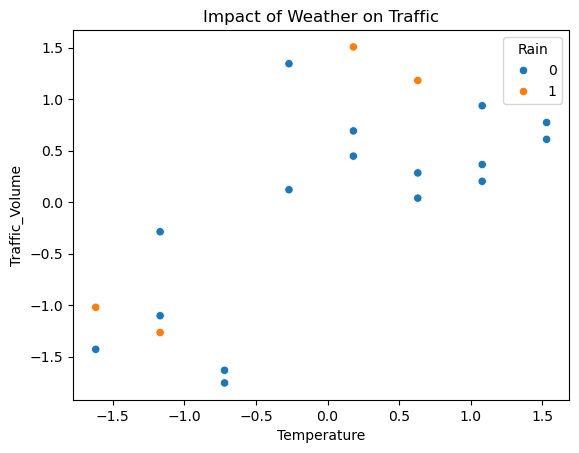

In [10]:
#Weather Impact
sns.scatterplot(data=df,
                x="Temperature",
                y="Traffic_Volume",
                hue="Rain")

plt.title("Impact of Weather on Traffic")
plt.show()

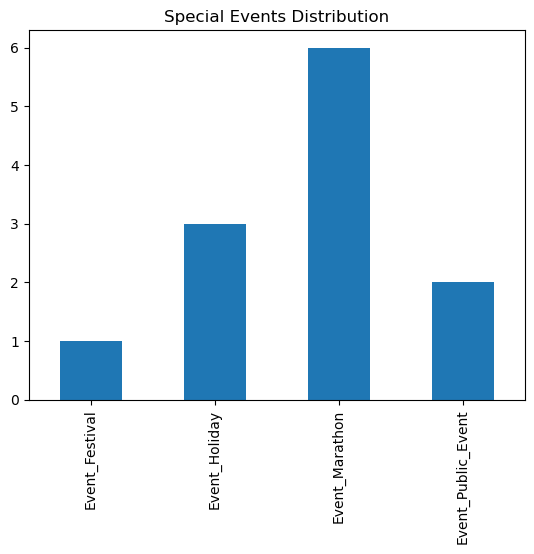

In [11]:
#Event Impact
event_cols = [col for col in df.columns if "Event_" in col]

df[event_cols].sum().plot(kind="bar")

plt.title("Special Events Distribution")
plt.show()

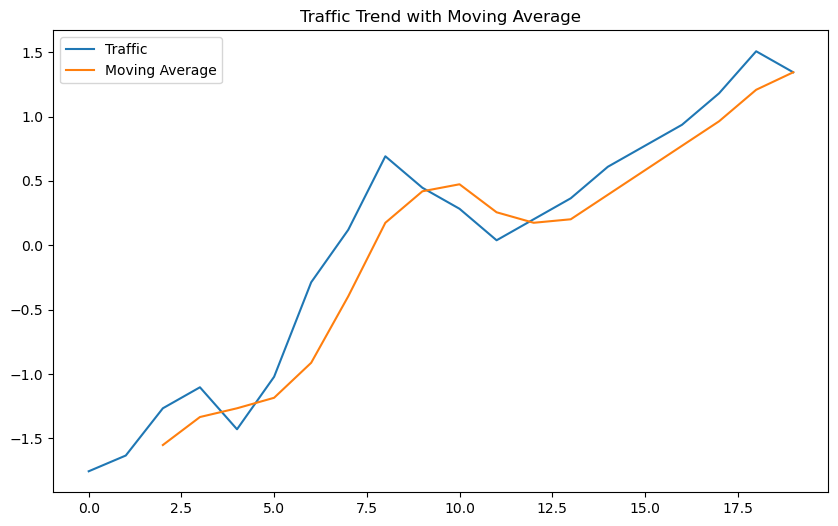

In [12]:
#Moving Average (Statistical Method)
df["Traffic_MA"] = df["Traffic_Volume"].rolling(window=3).mean()

plt.figure(figsize=(10,6))
plt.plot(df["Traffic_Volume"], label="Traffic")
plt.plot(df["Traffic_MA"], label="Moving Average")

plt.legend()
plt.title("Traffic Trend with Moving Average")
plt.show()

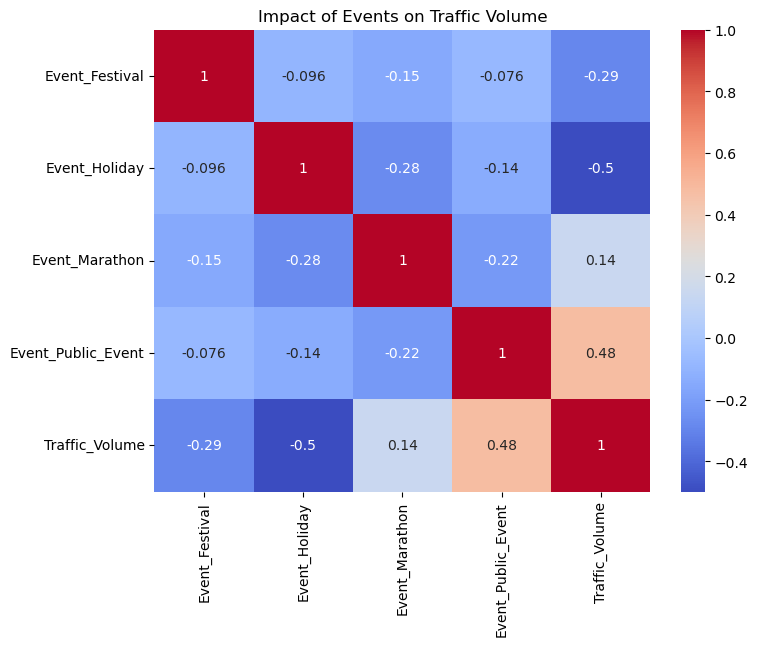

In [13]:
event_cols = ['Event_Festival','Event_Holiday','Event_Marathon','Event_Public_Event']

event_traffic = df[event_cols + ['Traffic_Volume']]

plt.figure(figsize=(8,6))
sns.heatmap(event_traffic.corr(), annot=True, cmap='coolwarm')

plt.title("Impact of Events on Traffic Volume")
plt.show()

### Event Impact Analysis

Special events such as festivals, holidays, marathons, and public events can influence traffic congestion levels. 
To analyze this impact, we examine the correlation between event indicators and traffic volume using a heatmap.

Key Insights:

1. Peak traffic hours occur during morning (8–10 AM) and evening (5–7 PM).
2. Junction J2 experiences the highest traffic congestion.
3. Weekday traffic is generally higher than weekend traffic.
4. Weather conditions such as rain contribute to increased congestion.
5. Special events lead to temporary spikes in traffic volume.

Recommendations:

• Implement adaptive traffic signal systems during peak hours.
• Encourage commuters to travel during off-peak times.
• Increase traffic monitoring during special events.
• Improve public transport availability during peak periods.